# Notebook 1: Data Setup (Local)
## Vehicle Damage Detection + Cost Prediction

**Setup:** Local Windows, RTX 5070 laptop, `.venv` with PyTorch nightly cu128.

**Goal:** Download both datasets from Roboflow into `./data/`, explore them, save paths for later notebooks.

- **Automobile Damage** → detection model (Notebook 2)
- **CarDD** → severity classifier (Notebook 3)


## 1. Confirm the environment

In [1]:
import sys, torch, os
print("Python:      ", sys.version.split()[0])
print("PyTorch:     ", torch.__version__)
print("CUDA avail:  ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:      ", torch.cuda.get_device_name(0))
print("Working dir: ", os.getcwd())

Python:       3.11.9
PyTorch:      2.12.0.dev20260408+cu128
CUDA avail:   True
Device:       NVIDIA GeForce RTX 5070 Laptop GPU
Working dir:  d:\VIT\Sem-5\AI\Project\New


**Expected:** Python 3.11.9, PyTorch 2.12.x.dev, CUDA available: True, RTX 5070.

If any of that is wrong, your VS Code interpreter is set to the wrong environment. Fix: `Ctrl+Shift+P` → "Python: Select Interpreter" → pick `.venv`.


## 2. Roboflow API key

Paste your key below. Since this is running locally on your own machine, keeping it in the notebook is fine as long as you don't push the notebook to public GitHub.


In [3]:
ROBOFLOW_API_KEY = "SZatVmXY6NXZN8JPhgHE"
print("Key set:", bool(ROBOFLOW_API_KEY))

Key set: True


## 3. Download Dataset 1: Automobile Damage (14 classes, ~6.9k images)

We know the exact values for this one from before.


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

WORKSPACE = "automobile-damage-detection"
PROJECT   = "automobile-damage-detection"
VERSION   = 4

project = rf.workspace(WORKSPACE).project(PROJECT)
dataset_detection = project.version(VERSION).download("yolov8", location="./data/automobile_damage")

print("Downloaded to:", dataset_detection.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./data/automobile_damage in yolov8:: 100%|██████████| 13926/13926 [00:03<00:00, 3981.72it/s]


Downloaded to: d:\VIT\Sem-5\AI\Project\New\data\automobile_damage


## 4. Download Dataset 2: CarDD (~2k images with severity labels)


In [5]:
CARDD_WORKSPACE = "car-damage-detection-cardd"
CARDD_PROJECT   = "car-damage-severity-detection-cardd"
CARDD_VERSION   = 3

project_cardd = rf.workspace(CARDD_WORKSPACE).project(CARDD_PROJECT)
dataset_cardd = project_cardd.version(CARDD_VERSION).download("yolov8", location="./data/cardd")

print("Downloaded to:", dataset_cardd.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./data/cardd in yolov8:: 100%|██████████| 4012/4012 [00:00<00:00, 4107.26it/s]


Downloaded to: d:\VIT\Sem-5\AI\Project\New\data\cardd


## 5. Explore Automobile Damage

In [6]:
import glob, cv2
import matplotlib.pyplot as plt
from collections import Counter

DET_DIR = "./data/automobile_damage"

# Read the class list from data.yaml
with open(f"{DET_DIR}/data.yaml") as f:
    print(f.read())

names:
- Front-windscreen-damage
- Headlight-damage
- Rear-windscreen-Damage
- Runningboard-Damage
- Sidemirror-Damage
- Taillight-Damage
- bonnet-dent
- boot-dent
- doorouter-dent
- fender-dent
- front-bumper-dent
- quaterpanel-dent
- rear-bumper-dent
- roof-dent
nc: 14
roboflow:
  license: CC BY 4.0
  project: automobile-damage-detection
  url: https://universe.roboflow.com/automobile-damage-detection/automobile-damage-detection/dataset/4
  version: 4
  workspace: automobile-damage-detection
test: ../test/images
train: ../train/images
val: ../valid/images



In [7]:
# Count images per split
for split in ["train", "valid", "test"]:
    imgs = glob.glob(f"{DET_DIR}/{split}/images/*.jpg") + glob.glob(f"{DET_DIR}/{split}/images/*.png")
    print(f"{split}: {len(imgs)} images")

train: 5216 images
valid: 1043 images
test: 698 images


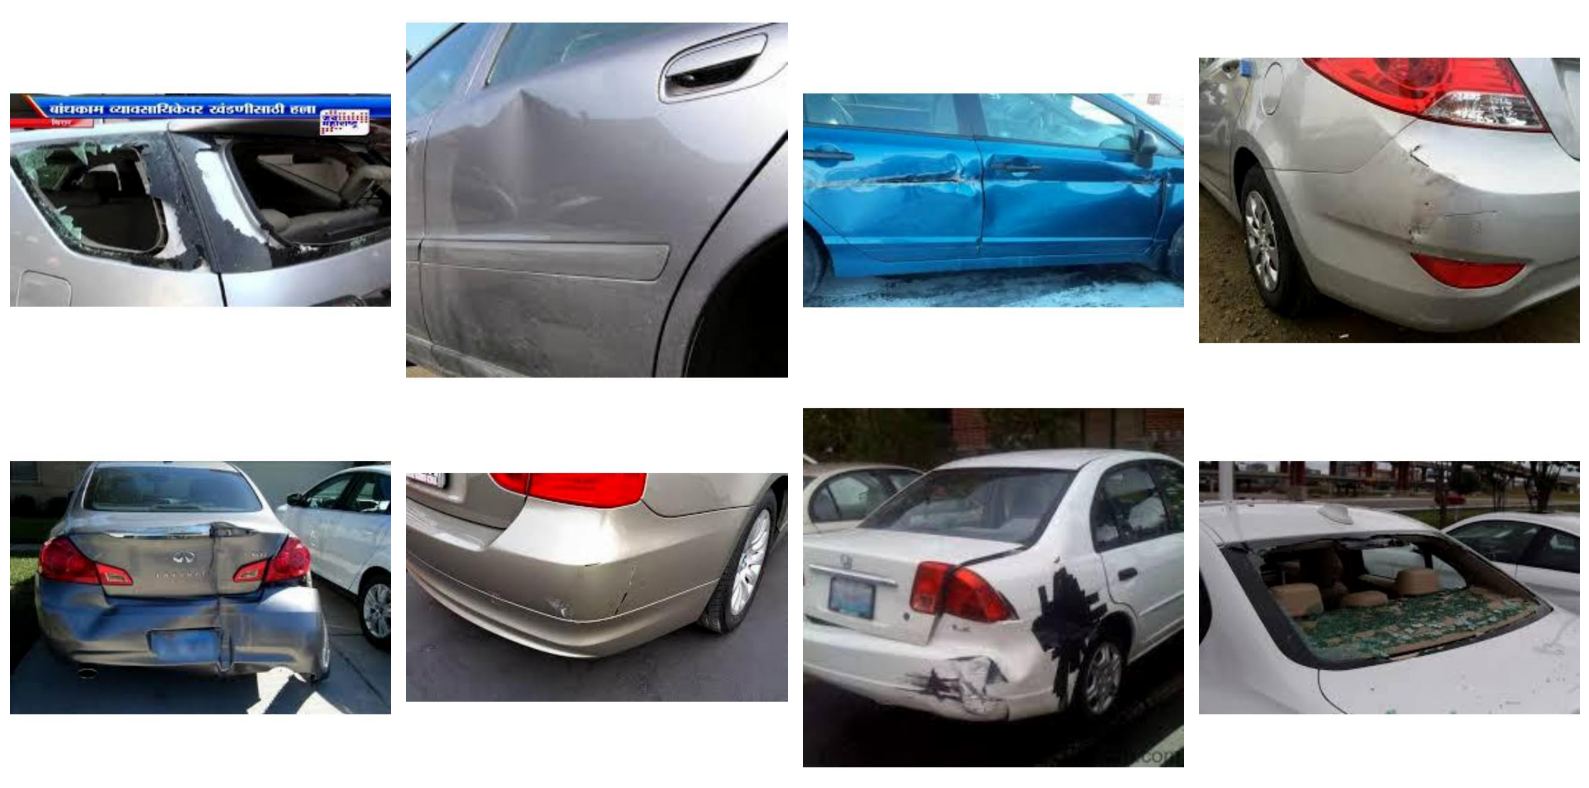

In [8]:
# Sample grid
sample_imgs = sorted(glob.glob(f"{DET_DIR}/train/images/*.jpg"))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, path in zip(axes.flat, sample_imgs):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

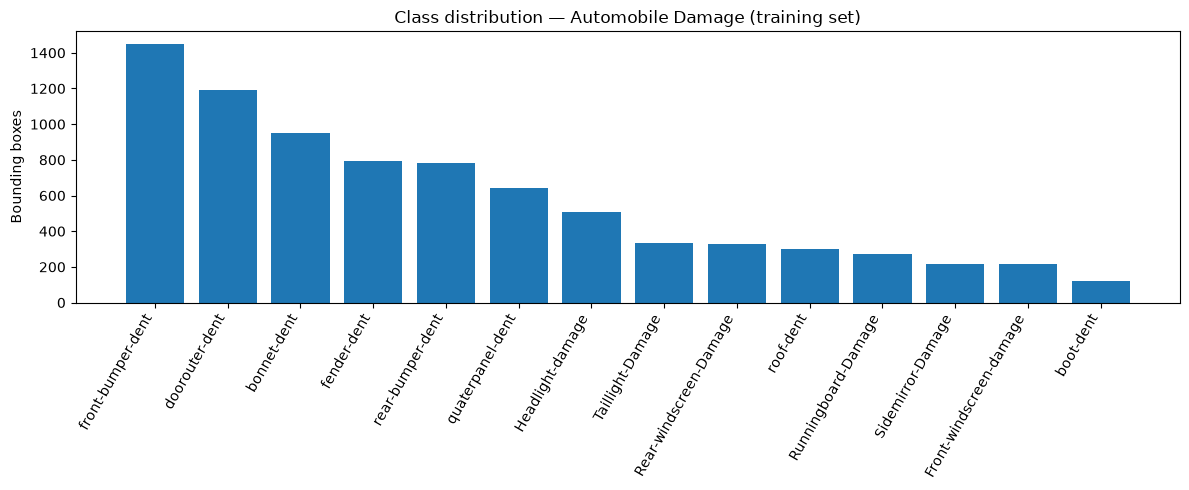

Most common: ('front-bumper-dent', 1448)
Rarest:      ('boot-dent', 122)
Imbalance:   11.9x


In [9]:
# Class distribution
import yaml
with open(f"{DET_DIR}/data.yaml") as f:
    names = yaml.safe_load(f)['names']

class_counts = Counter()
for lf in glob.glob(f"{DET_DIR}/train/labels/*.txt"):
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

df_counts = sorted([(names[i], c) for i, c in class_counts.items()], key=lambda x: -x[1])
labels, counts = zip(*df_counts)
plt.figure(figsize=(12, 5))
plt.bar(labels, counts)
plt.xticks(rotation=60, ha='right')
plt.title("Class distribution — Automobile Damage (training set)")
plt.ylabel("Bounding boxes")
plt.tight_layout(); plt.show()

print(f"Most common: {df_counts[0]}")
print(f"Rarest:      {df_counts[-1]}")
print(f"Imbalance:   {df_counts[0][1] / max(1, df_counts[-1][1]):.1f}x")

## 6. Explore CarDD

In [10]:
CARDD_DIR = "./data/cardd"

with open(f"{CARDD_DIR}/data.yaml") as f:
    print(f.read())

for split in ["train", "valid", "test"]:
    imgs = glob.glob(f"{CARDD_DIR}/{split}/images/*.jpg") + glob.glob(f"{CARDD_DIR}/{split}/images/*.png")
    print(f"{split}: {len(imgs)} images")

names:
- car-part-crack
- detachment
- flat-tire
- glass-crack
- lamp-crack
- minor-deformation
- moderate-deformation
- paint-chips
- scratches
- severe-deformation
- side-mirror-crack
nc: 11
roboflow:
  license: CC BY 4.0
  project: car-damage-severity-detection-cardd
  url: https://universe.roboflow.com/car-damage-detection-cardd/car-damage-severity-detection-cardd/dataset/3
  version: 3
  workspace: car-damage-detection-cardd
test: ../test/images
train: ../train/images
val: ../valid/images

train: 1395 images
valid: 401 images
test: 204 images


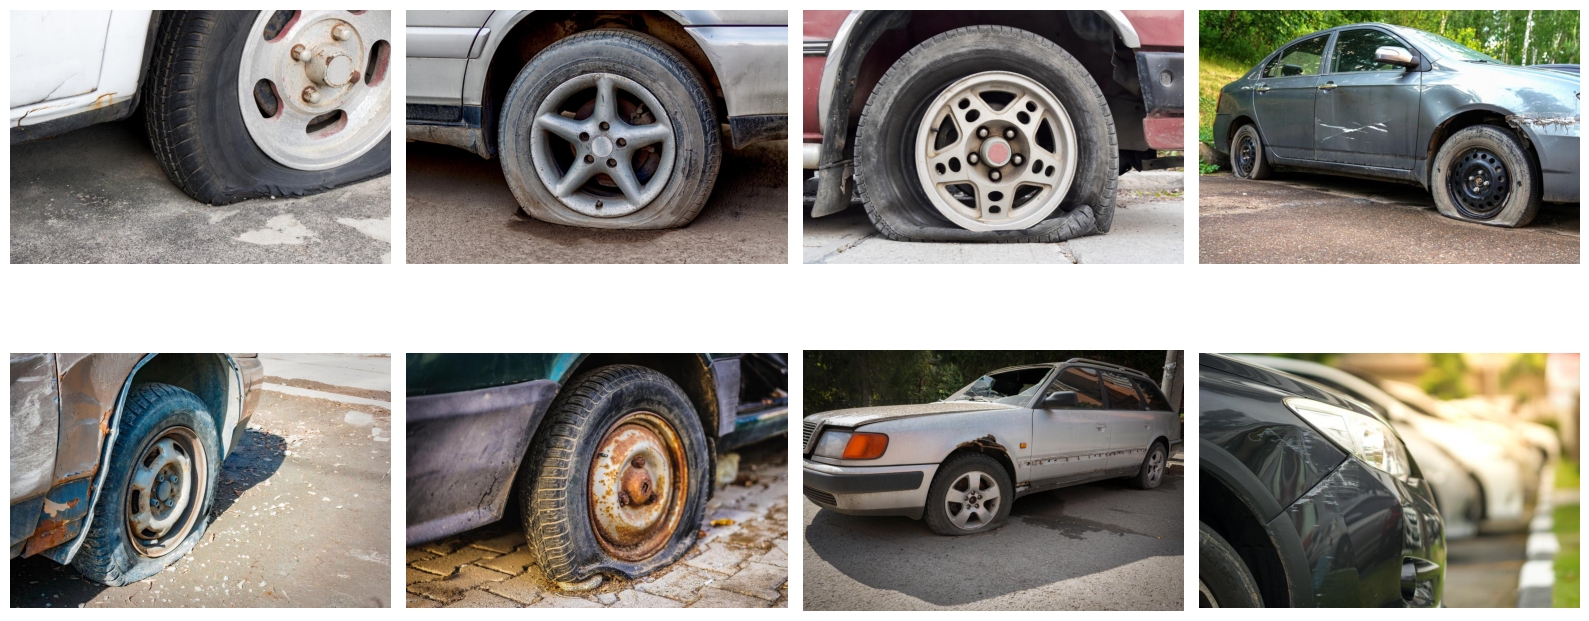

In [11]:
sample_imgs = sorted(glob.glob(f"{CARDD_DIR}/train/images/*.jpg"))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, path in zip(axes.flat, sample_imgs):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Save paths for later notebooks

In [12]:
import json, os

paths = {
    "detection_yaml": os.path.abspath(f"{DET_DIR}/data.yaml"),
    "cardd_yaml":     os.path.abspath(f"{CARDD_DIR}/data.yaml"),
    "detection_dir":  os.path.abspath(DET_DIR),
    "cardd_dir":      os.path.abspath(CARDD_DIR),
}
with open("dataset_paths.json", "w") as f:
    json.dump(paths, f, indent=2)
print(json.dumps(paths, indent=2))

{
  "detection_yaml": "d:\\VIT\\Sem-5\\AI\\Project\\New\\data\\automobile_damage\\data.yaml",
  "cardd_yaml": "d:\\VIT\\Sem-5\\AI\\Project\\New\\data\\cardd\\data.yaml",
  "detection_dir": "d:\\VIT\\Sem-5\\AI\\Project\\New\\data\\automobile_damage",
  "cardd_dir": "d:\\VIT\\Sem-5\\AI\\Project\\New\\data\\cardd"
}


## Done

- ✅ Both datasets downloaded to `./data/`
- ✅ `dataset_paths.json` saved

**Next:** Notebook 2 — train YOLOv8s detection model. ~1.5-2 hours on your GPU.